In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Download latest version
path = kagglehub.dataset_download("lucalullo/european-employment-unemployment-rates-2015-2024")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Nayan\.cache\kagglehub\datasets\lucalullo\european-employment-unemployment-rates-2015-2024\versions\1


In [2]:
print(os.listdir(path))

['disoccupazione.csv', 'occupazione.csv']


In [ ]:

# Join the download path with a specific file name
occupy = pd.read_csv(os.path.join(path, 'disoccupazione.csv'))

Understanding UnEmployed Dataset and Doing Analysis

In [ ]:
occupy.head()

,SEX,AGE,ISO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,F,15-19,AT,11.7,14.6,14.4,12.3,10.1,11.8,14.1,15.7,14.9,14.7
1,F,15-19,BA,NaN,NaN,NaN,NaN,NaN,NaN,63.1,54.7,NaN,56.8
2,F,15-19,BE,28.2,26.8,19.0,19.8,17.1,20.3,19.7,18.6,19.7,21.3
3,F,15-19,BG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F,15-19,CH,9.7,9.0,8.9,9.0,8.3,9.0,9.9,8.0,9.4,11.0


In [ ]:
occupy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEX     2450 non-null   object 
 1   AGE     2450 non-null   object 
 2   ISO     2450 non-null   object 
 3   2015    2177 non-null   float64
 4   2016    2159 non-null   float64
 5   2017    2137 non-null   float64
 6   2018    2135 non-null   float64
 7   2019    2120 non-null   float64
 8   2020    2148 non-null   float64
 9   2021    2156 non-null   object 
 10  2022    2126 non-null   object 
 11  2023    2100 non-null   object 
 12  2024    2118 non-null   object 
dtypes: float64(6), object(7)
memory usage: 249.0+ KB


In [ ]:
occupy.isnull().sum()

SEX       0
AGE       0
ISO       0
2015    273
2016    291
2017    313
2018    315
2019    330
2020    302
2021    294
2022    324
2023    350
2024    332
dtype: int64

In [ ]:
occupy.columns

Index(['SEX', 'AGE', 'ISO', '2015', '2016', '2017', '2018', '2019', '2020',
       '2021', '2022', '2023', '2024'],
      dtype='object')

In [ ]:
occupy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEX     2450 non-null   object 
 1   AGE     2450 non-null   object 
 2   ISO     2450 non-null   object 
 3   2015    2177 non-null   float64
 4   2016    2159 non-null   float64
 5   2017    2137 non-null   float64
 6   2018    2135 non-null   float64
 7   2019    2120 non-null   float64
 8   2020    2148 non-null   float64
 9   2021    2156 non-null   object 
 10  2022    2126 non-null   object 
 11  2023    2100 non-null   object 
 12  2024    2118 non-null   object 
dtypes: float64(6), object(7)
memory usage: 249.0+ KB


In [ ]:
a = occupy[occupy['2021']=='5.1u']
a

,SEX,AGE,ISO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1133,F,65-69,FR,2.9,4.4,2.5,NaN,4.4,NaN,5.1u,5.5u,3.5u,2.7u
2358,M,65-69,FR,3.1,2.1,4.8,NaN,NaN,NaN,5.1u,3.9u,5.8,5.6


In [10]:
a1 = a['2021'][0:1]
a1.replace('u','', regex=True).astype(float)
    

1133    5.1
Name: 2021, dtype: float64

handling 'u' present in the columns

In [ ]:
for i in ['2015', '2016', '2017', '2018', '2019', '2020','2021', '2022', '2023', '2024']:
    occupy[i] = occupy[i].replace('u','', regex=True)
    occupy[i] = occupy[i].astype(float)
    occupy[i] = occupy[i].fillna(occupy[i].mean())

In [ ]:
occupy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEX     2450 non-null   object 
 1   AGE     2450 non-null   object 
 2   ISO     2450 non-null   object 
 3   2015    2450 non-null   float64
 4   2016    2450 non-null   float64
 5   2017    2450 non-null   float64
 6   2018    2450 non-null   float64
 7   2019    2450 non-null   float64
 8   2020    2450 non-null   float64
 9   2021    2450 non-null   float64
 10  2022    2450 non-null   float64
 11  2023    2450 non-null   float64
 12  2024    2450 non-null   float64
dtypes: float64(10), object(3)
memory usage: 249.0+ KB


In [ ]:
occupy

,SEX,AGE,ISO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,F,15-19,AT,11.700000,14.600000,14.400000,12.300000,10.100000,11.800000,14.100000,15.700000,14.900000,14.700000
1,F,15-19,BA,11.127331,10.236174,9.184043,8.196956,7.626698,8.373231,63.100000,54.700000,7.135762,56.800000
2,F,15-19,BE,28.200000,26.800000,19.000000,19.800000,17.100000,20.300000,19.700000,18.600000,19.700000,21.300000
3,F,15-19,BG,11.127331,10.236174,9.184043,8.196956,7.626698,8.373231,8.318831,7.301176,7.135762,7.085269
4,F,15-19,CH,9.700000,9.000000,8.900000,9.000000,8.300000,9.000000,9.900000,8.000000,9.400000,11.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2445,M,70-74,RS,11.127331,10.236174,9.184043,8.196956,7.626698,8.373231,8.318831,7.301176,7.135762,7.085269
2446,M,70-74,SE,11.127331,10.236174,3.900000,8.196956,7.626698,8.373231,8.318831,7.301176,7.135762,7.085269
2447,M,70-74,SI,11.127331,10.236174,9.184043,8.196956,7.626698,8.373231,8.318831,7.301176,7.135762,7.085269
2448,M,70-74,SK,11.127331,10.236174,9.184043,8.196956,7.626698,8.373231,8.318831,7.301176,7.135762,7.085269


Visualizing

In [ ]:
occupy.AGE.value_counts()

AGE
15-19    70
15-24    70
15-29    70
15-39    70
15-59    70
15-64    70
15-74    70
20-24    70
20-29    70
20-64    70
25-29    70
25-49    70
25-54    70
25-59    70
25-64    70
25-74    70
30-34    70
30-54    70
30-64    70
30-74    70
35-39    70
40-44    70
40-59    70
40-64    70
45-49    70
50-54    70
50-59    70
50-64    70
50-74    70
55-59    70
55-64    70
60-64    70
65-69    70
65-74    70
70-74    70
Name: count, dtype: int64

In [ ]:
occupy.SEX.value_counts()

SEX
F    1225
M    1225
Name: count, dtype: int64

In [ ]:
occupy.ISO.value_counts()

ISO
AT    70
BA    70
BE    70
BG    70
CH    70
CY    70
CZ    70
DE    70
DK    70
EE    70
GR    70
ES    70
FI    70
FR    70
HR    70
HU    70
IE    70
IS    70
IT    70
LT    70
LU    70
LV    70
ME    70
MK    70
MT    70
NL    70
NO    70
PL    70
PT    70
RO    70
RS    70
SE    70
SI    70
SK    70
TR    70
Name: count, dtype: int64

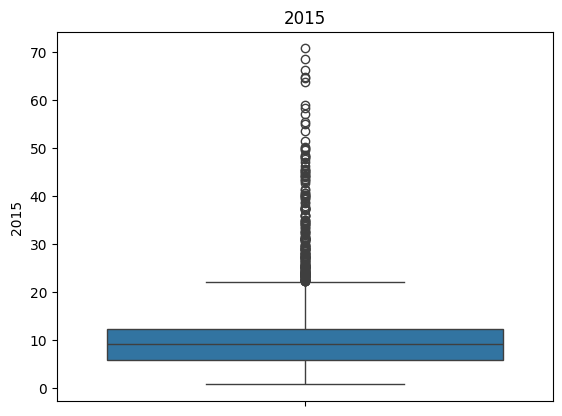

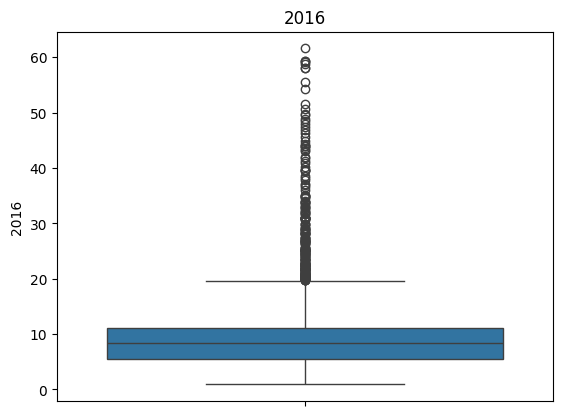

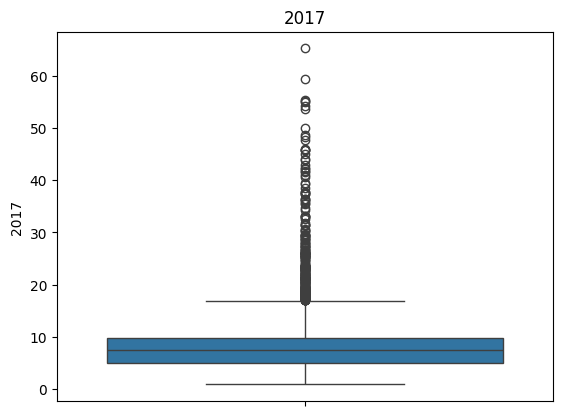

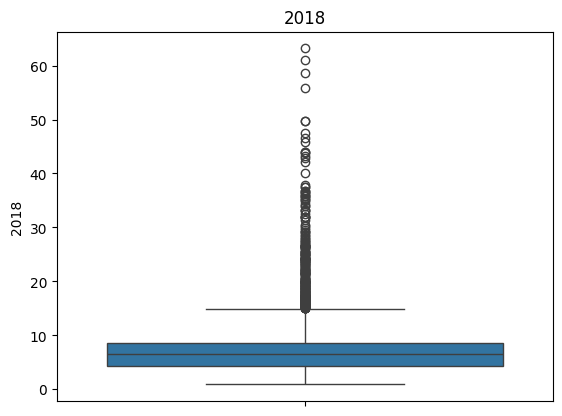

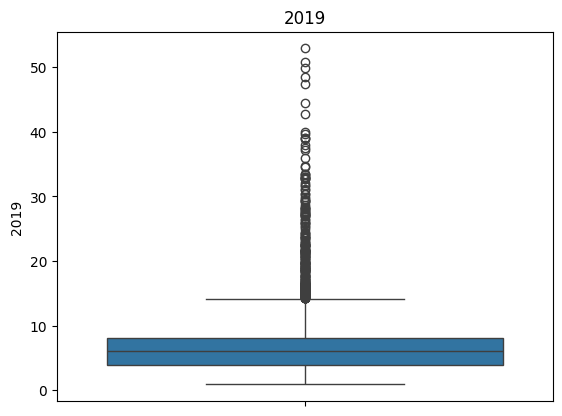

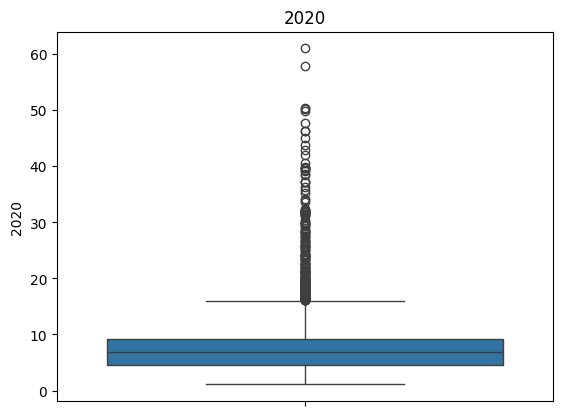

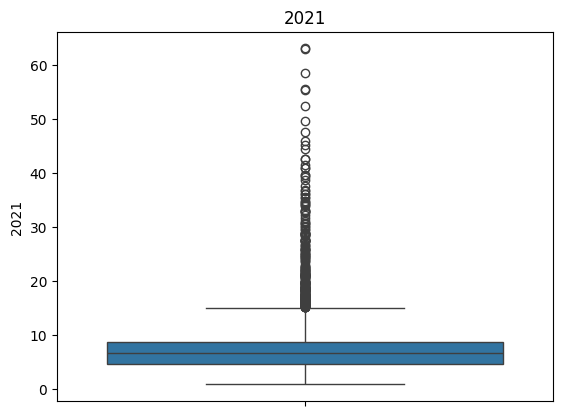

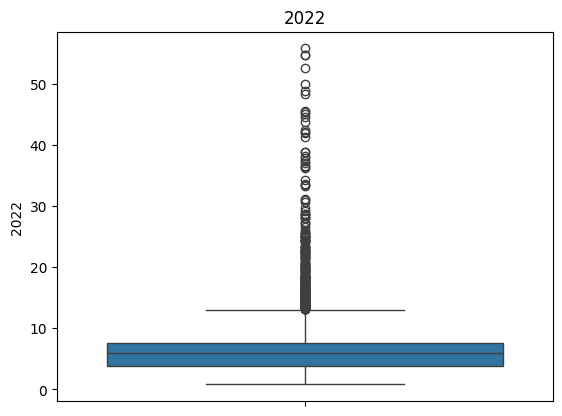

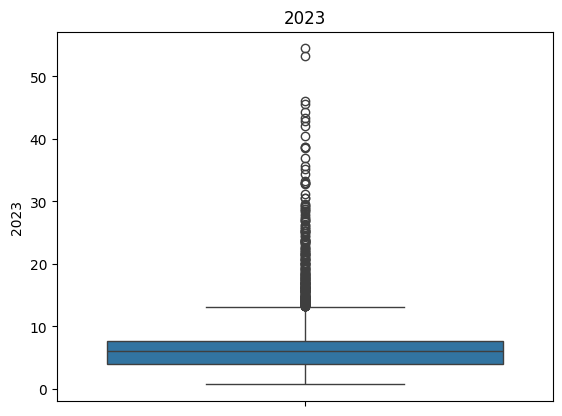

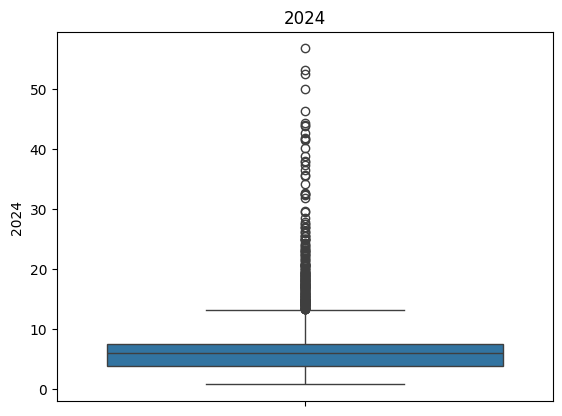

In [ ]:
for i in ['2015', '2016', '2017', '2018', '2019', '2020','2021', '2022', '2023', '2024']:
    sns.boxplot(occupy[i])
    plt.title(i)
    plt.show()

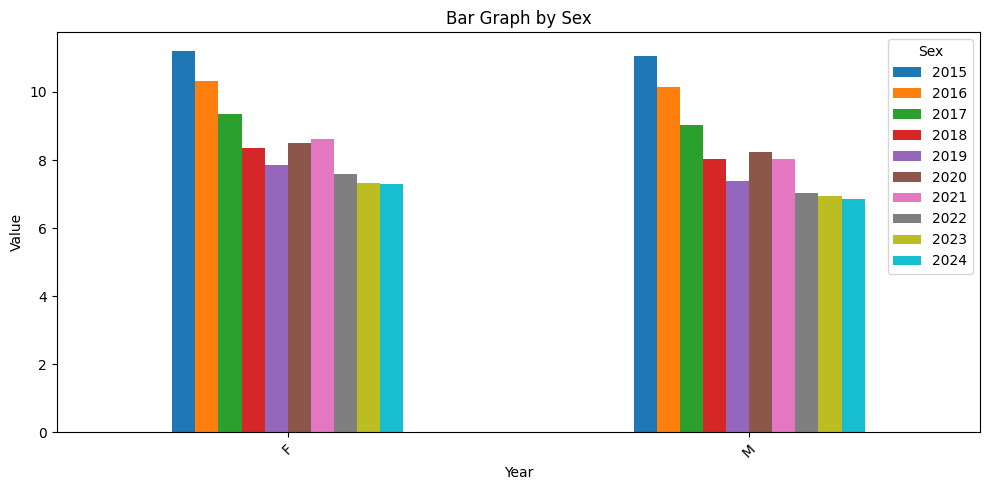

In [ ]:
# transpose for plotting
cols = ['2015', '2016', '2017', '2018', '2019', '2020','2021', '2022', '2023', '2024']
df_plot = occupy.groupby('SEX')[cols].mean()
df_plot.plot(kind='bar', figsize=(10,5))

plt.title("Bar Graph by Sex")
plt.xlabel("Year")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.tight_layout()

plt.show()


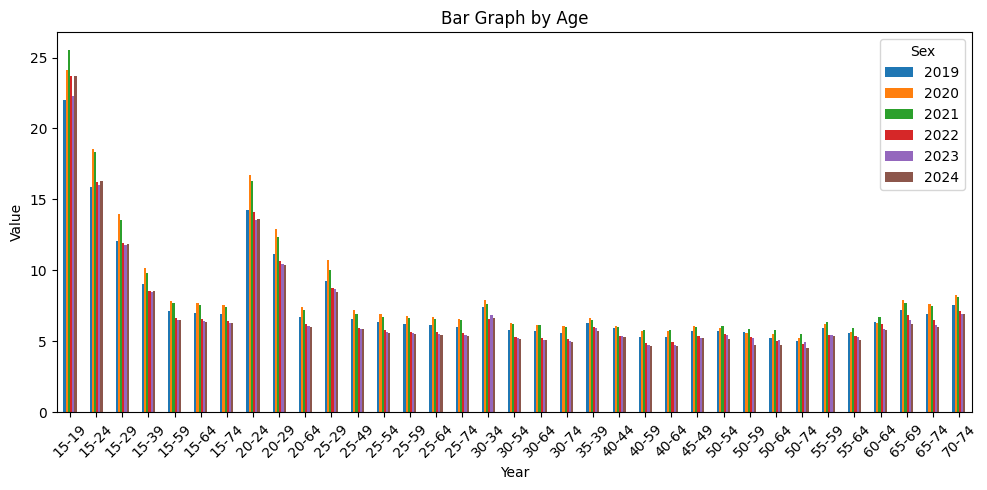

In [ ]:
# transpose for plotting
cols = ['2019', '2020','2021', '2022', '2023', '2024']
df_plot = occupy.groupby('AGE')[cols].mean()
df_plot.plot(kind='bar', figsize=(10,5))

plt.title("Bar Graph by Age")
plt.xlabel("Year")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.tight_layout()

plt.show()


In [58]:
df_plot

AGE,index,15-19,15-24,15-29,15-39,15-59,15-64,15-74,20-24,20-29,...,50-54,50-59,50-64,50-74,55-59,55-64,60-64,65-69,65-74,70-74
0,2019,21.983530,15.846477,12.102191,9.012191,7.135049,7.007906,6.896477,14.242573,11.122191,...,5.756671,5.655527,5.238287,5.008287,5.918863,5.615908,6.336678,7.212121,6.951358,7.543460
1,2020,24.122835,18.529235,14.002092,10.153521,7.854949,7.699235,7.564949,16.723521,12.929235,...,5.961226,5.624949,5.552092,5.267807,6.210844,5.664567,6.318831,7.942387,7.650677,8.280756
2,2021,25.499481,18.324824,13.584824,9.814824,7.694824,7.576252,7.457681,16.269378,12.344824,...,6.099026,5.889378,5.773395,5.543395,6.356438,5.915093,6.739128,7.723905,7.524258,8.161150
3,2022,23.725949,16.237176,11.901462,8.551462,6.637176,6.548605,6.451462,14.121496,10.644319,...,5.543042,5.275832,5.025765,4.845765,5.475899,5.345832,6.190319,6.838084,6.479462,7.121126
4,2023,22.285724,15.985818,11.768165,8.513879,6.526736,6.416736,6.319593,13.560208,10.449593,...,5.439499,5.206027,5.083576,4.933576,5.469499,5.282252,5.863075,6.531363,6.175033,6.964229
5,2024,23.701129,16.271008,11.876722,8.542436,6.499579,6.386722,6.281008,13.627940,10.399579,...,5.184197,4.730166,4.727519,4.564662,5.372768,5.105249,5.788859,6.250696,5.989899,6.920186


this shows, the unemployment rate goes below from age above and equal to 25 years of old.

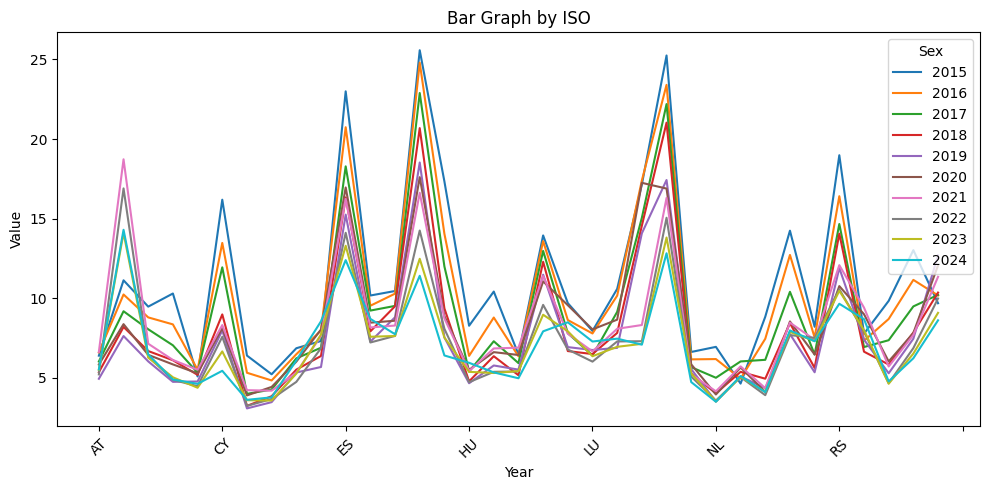

In [ ]:
# transpose for plotting
cols = ['2015', '2016', '2017', '2018', '2019', '2020','2021', '2022', '2023', '2024']
df_plot = .groupby('ISO')[cols].mean()
df_plot.plot(kind='line', figsize=(10,5))

plt.title("Bar Graph by ISO")
plt.xlabel("Year")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.tight_layout()

plt.show()


the unemployment raises for 2016 and 2024 for every region present in above graph

Employment 

In [ ]:
occupy = pd.read_csv(os.path.join(path, 'occupazione.csv'))
occupy.head()

,SEX,AGE,ISO,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,F,15-24,AT,48.7,49.0,49.0,48.7,48.4,47.1,45.7,48.2,49.8,48.3
1,F,15-24,BA,NaN,NaN,NaN,NaN,NaN,NaN,13.7,12.3,11.5,10.4
2,F,15-24,BE,21.7,21.4,20.9,23.5,25.8,22.3,23.7,25.4,25.9,25.2
3,F,15-24,BG,14.0,13.8,16.3,14.5,15.6,13.4,13.0,15.9,16.2,13.7
4,F,15-24,CH,62.6,63.2,62.4,62.6,61.6,59.4,59.5,60.2,59.9,59.1


In [67]:
occupy.isnull().sum()

SEX      0
AGE      0
ISO      0
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
dtype: int64

In [68]:
for i in ['2015', '2016', '2017', '2018', '2019', '2020','2021', '2022', '2023', '2024']:
    occupy[i] = occupy[i].replace('u','', regex=True)
    occupy[i] = occupy[i].astype(float)
    occupy[i] = occupy[i].fillna(occupy[i].mean())

In [69]:
occupy.isnull().sum()

SEX     0
AGE     0
ISO     0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
dtype: int64

In [70]:
occupy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SEX     420 non-null    object 
 1   AGE     420 non-null    object 
 2   ISO     420 non-null    object 
 3   2015    420 non-null    float64
 4   2016    420 non-null    float64
 5   2017    420 non-null    float64
 6   2018    420 non-null    float64
 7   2019    420 non-null    float64
 8   2020    420 non-null    float64
 9   2021    420 non-null    float64
 10  2022    420 non-null    float64
 11  2023    420 non-null    float64
 12  2024    420 non-null    float64
dtypes: float64(10), object(3)
memory usage: 42.8+ KB


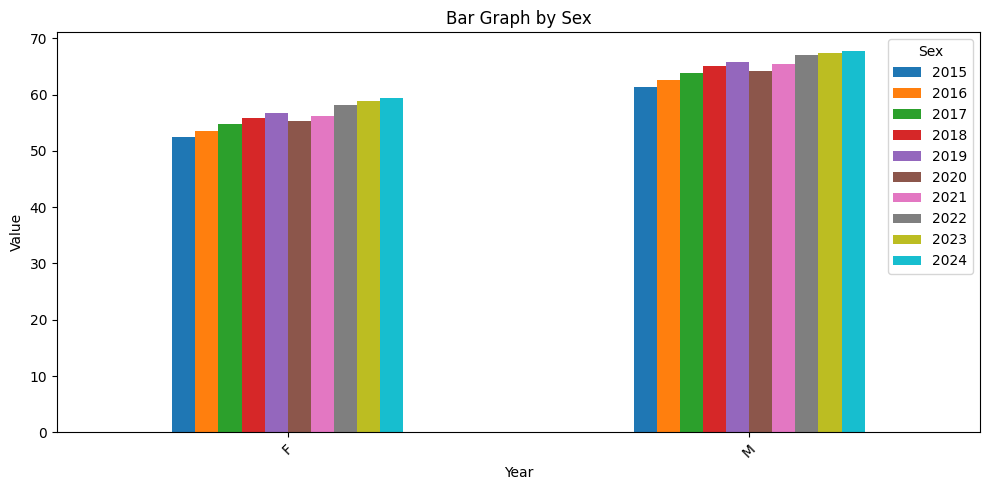

In [71]:
# transpose for plotting
cols = ['2015', '2016', '2017', '2018', '2019', '2020','2021', '2022', '2023', '2024']
df_plot = occupy.groupby('SEX')[cols].mean()
df_plot.plot(kind='bar', figsize=(10,5))

plt.title("Bar Graph by Sex")
plt.xlabel("Year")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.tight_layout()

plt.show()


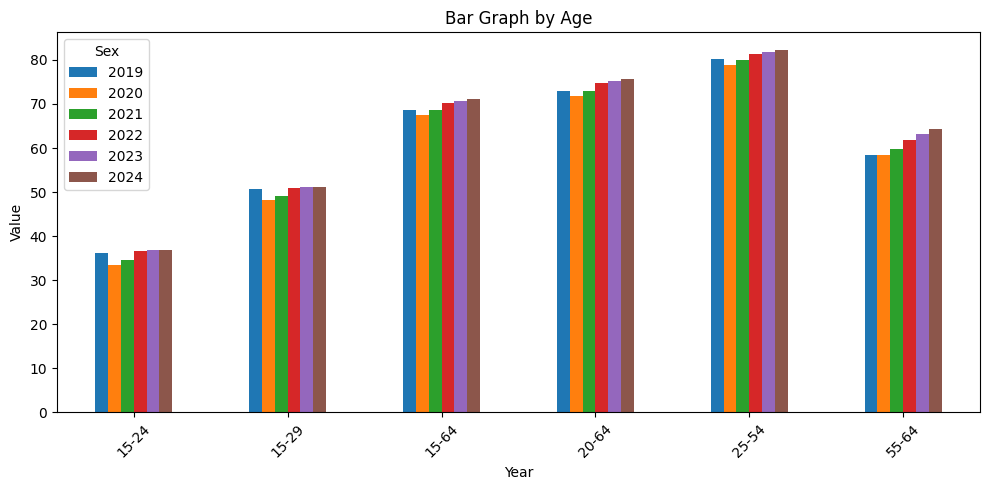

In [72]:
# transpose for plotting
cols = ['2019', '2020','2021', '2022', '2023', '2024']
df_plot = occupy.groupby('AGE')[cols].mean()
df_plot.plot(kind='bar', figsize=(10,5))

plt.title("Bar Graph by Age")
plt.xlabel("Year")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.tight_layout()

plt.show()


as per the above graph, we can see the value increasing for each year for 15-64 and 25-25 years age group

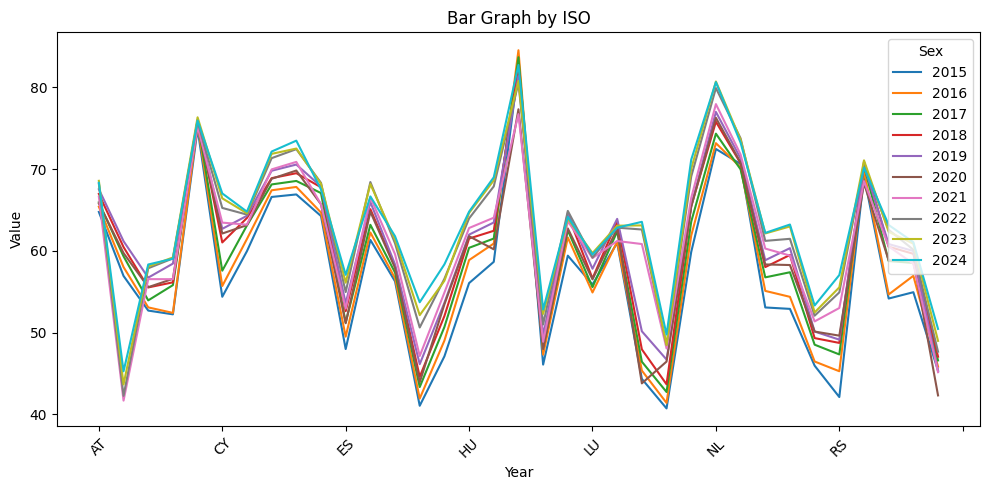

In [74]:
# transpose for plotting
cols = ['2015', '2016', '2017', '2018', '2019', '2020','2021', '2022', '2023', '2024']
df_plot = occupy.groupby('ISO')[cols].mean()
df_plot.plot(kind='line', figsize=(10,5))

plt.title("Bar Graph by ISO")
plt.xlabel("Year")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend(title="Sex")
plt.tight_layout()

plt.show()


the 2024 years has more people employed.
the 2020 years, has less people employed may be because of covid